In [84]:
import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
from torch_geometric.nn.conv import GATConv, GCNConv, SplineConv
from torch_geometric.nn.norm import GraphNorm
import argparse
from torch_geometric.nn import Sequential
from torch_geometric.data import Data, Batch
from dataset import WaveletDataset
from torch_geometric.loader import DataLoader
import torch.utils.data as torchdata
import tqdm
from math import floor
import gc
import matplotlib.pyplot as plt 
from Model.MENDR.mAtt.optimizer import MixOptimizer
import random
import os
import math
from dataset import WaveletTUABDataset
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, precision_recall_curve, auc
from Finetuning.biot import BIOTEncoder, ClassificationHead
from torch.utils.data import Subset
import pickle
from scipy.signal import butter, sosfilt, resample

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [106]:
class TUABLoader(torch.utils.data.Dataset):
    def __init__(self, root, files, sampling_rate=200):
        self.root = root
        self.files = files
        self.default_rate = 200
        self.sampling_rate = sampling_rate
        self.filter = butter(2, [0.1, 75], btype='bandpass', fs=self.default_rate, output='sos')

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        sample = pickle.load(open(os.path.join(self.root, self.files[index]), "rb"))
        X = sample["X"]
        X = sosfilt(self.filter, X, axis=-1)
        # from default 200Hz to ?
        if self.sampling_rate != self.default_rate:
            X = resample(X, 10 * self.sampling_rate, axis=-1)
        X = X / (
            np.quantile(np.abs(X), q=0.95, method="linear", axis=-1, keepdims=True)
            + 1e-8
        )
        Y = sample["y"]
        X = torch.FloatTensor(X)
        return X, Y

In [107]:
def prepare_TUAB_dataloader(args):
    # set random seed
    seed = 12345
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)

    root = "/home/hice1/mchen439/scratch/eegtrue"

    train_files = os.listdir(os.path.join(root, "train"))
    np.random.shuffle(train_files)
    # train_files = train_files[:100000]
    val_files = os.listdir(os.path.join(root, "val"))
    test_files = os.listdir(os.path.join(root, "test"))

    print(len(train_files), len(val_files), len(test_files))

    # prepare training and test data loader
    train_loader = torch.utils.data.DataLoader(
        TUABLoader(os.path.join(root, "train"),
                   train_files, args.sampling_rate),
        batch_size=args.batch_size,
        shuffle=True,
        drop_last=True,
        num_workers=args.num_workers,
        persistent_workers=True,
    )
    test_loader = torch.utils.data.DataLoader(
        TUABLoader(os.path.join(root, "test"), test_files, args.sampling_rate),
        batch_size=args.batch_size,
        shuffle=False,
        num_workers=args.num_workers,
        persistent_workers=True,
    )
    val_loader = torch.utils.data.DataLoader(
        TUABLoader(os.path.join(root, "val"), val_files, args.sampling_rate),
        batch_size=args.batch_size,
        shuffle=False,
        num_workers=args.num_workers,
        persistent_workers=True,
    )
    print(len(train_loader), len(val_loader), len(test_loader))
    return train_loader, test_loader, val_loader

In [108]:
parser = argparse.ArgumentParser()
parser.add_argument("--epochs", type=int, default=100,
                    help="number of epochs")
parser.add_argument("--lr", type=float, default=1e-3, help="learning rate")
parser.add_argument("--weight_decay", type=float,
                    default=1e-5, help="weight decay")
parser.add_argument("--batch_size", type=int,
                    default=512, help="batch size")
parser.add_argument("--num_workers", type=int,
                    default=8, help="number of workers")
parser.add_argument("--dataset", type=str, default="TUAB", help="dataset")
parser.add_argument(
    "--model", type=str, default="SPaRCNet", help="which supervised model to use"
)
parser.add_argument(
    "--in_channels", type=int, default=16, help="number of input channels"
)
parser.add_argument(
    "--sample_length", type=float, default=10, help="length (s) of sample"
)
parser.add_argument(
    "--n_classes", type=int, default=1, help="number of output classes"
)
parser.add_argument(
    "--sampling_rate", type=int, default=128, help="sampling rate (r)"
)
parser.add_argument("--token_size", type=int,
                    default=200, help="token size (t)")
parser.add_argument(
    "--hop_length", type=int, default=100, help="token hop length (t - p)"
)
parser.add_argument(
    "--pretrain_model_path", type=str, default="", help="pretrained model path"
)
args, _ = parser.parse_known_args()

In [109]:
train_loader, test_loader, val_loader = prepare_TUAB_dataloader(args)

300823 71687 36945
587 141 73


In [110]:
class BIOTClassifier(nn.Module):
    def __init__(self, emb_size=256, heads=8, depth=4, n_classes=1, **kwargs):
        super().__init__()
        self.biot = BIOTEncoder(emb_size=emb_size, heads=heads, depth=depth, n_channels=16, n_fft=128, hop_length=64, **kwargs)
        self.classifier = ClassificationHead(emb_size, n_classes)

    def forward(self, x):
        x = self.biot(x)
        x = self.classifier(x)
        return x

In [111]:
model = BIOTClassifier().to(device)
#model.biot.load_state_dict(torch.load("Finetuning/EEG-PREST-16-channels.ckpt"))
optim_params = []
optim_params += list(model.parameters())
optimizer = torch.optim.Adam(optim_params, lr=1e-3, weight_decay=1e-5)
print("Total parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Total parameters: 3177217


In [112]:
def train_one_epoch(model, optimizer, task_loss_fn, train_loader):
	loss_sum = 0
	model.train()

	pbar = tqdm.trange(len(train_loader), desc="Training")
	data_iterator = iter(train_loader)
	balanced_accuracies = []

	for iteration in pbar:
		x, y = next(data_iterator)

		x = x.to(device).float()
		y = y.to(device).float()
		#biot_input = data['graph'].x
		#biot_input = torch.from_numpy(np.array(biot_input)).float().to(device)
		#biot_input = biot_input[:, :16, :]
		#prediction = model(biot_input)
		#ground_truth = data['graph'].y.to(device).float()

		prediction = model(x)
		ground_truth = y 

		task_loss = task_loss_fn(prediction, ground_truth[:, None])

		with torch.no_grad():
			score_y = torch.sigmoid(prediction)
			pred_y = torch.gt(score_y, 0.5).long().cpu().numpy()
			score_y = score_y.cpu().numpy()

			balanced_accuracy = balanced_accuracy_score(ground_truth.cpu().numpy(), pred_y)
			accuracy = accuracy_score(ground_truth.cpu().numpy(), pred_y)
			roc_auc = roc_auc_score(ground_truth.cpu().numpy(), score_y)
			precision, recall, thresholds = precision_recall_curve(ground_truth.cpu().numpy(), score_y, pos_label=1)
			pr_auc = auc(recall, precision)

		balanced_accuracies.append(balanced_accuracy)

		loss = task_loss

		#optimizer.scheduler_step(iteration)

		optimizer.zero_grad()
		loss.backward()
		optimizer.step()
		loss_sum += loss.item()

		pbar.set_postfix(task_loss=task_loss.item(), accuracy=f'{accuracy*100:.3f}', balanced_accuracy=f'{balanced_accuracy*100:.3f}', AUROC=f'{roc_auc*100:.3f}', AUCPR=f'{pr_auc*100:.3f}')
	balanced_accuracies = np.array(balanced_accuracies)	
	print(f'Mean Acc: {balanced_accuracies.mean()} Acc Std: {balanced_accuracies.std()}')
	return loss_sum

In [113]:
def validate_one_epoch(model, task_loss_fn, val_loader):
    loss_sum = 0
    model.eval()

    pbar = tqdm.trange(len(val_loader), desc="Validating")
    data_iterator = iter(val_loader)
    balanced_accuracies = []

    with torch.no_grad():
        for iteration in pbar:
            x, y = next(data_iterator)

            x = x.to(device).float()
            y = y.to(device).float()

            ''' 
            biot_input = data['graph'].x
            biot_input = torch.from_numpy(np.array(biot_input)).float().to(device)
            biot_input = biot_input[:, :16, :]
            '''

            prediction = model(x)
            ground_truth = y 

            '''
            prediction = model(biot_input)
            ground_truth = data['graph'].y.to(device).float()
            '''
            
            task_loss = task_loss_fn(prediction, ground_truth[:, None])
            
            score_y = torch.sigmoid(prediction)
            
            pred_y = torch.gt(score_y, 0.5).long().cpu().numpy()
            score_y = score_y.cpu().numpy()
            balanced_accuracy = balanced_accuracy_score(ground_truth.cpu().numpy(), pred_y)
            accuracy = accuracy_score(ground_truth.cpu().numpy(), pred_y)
            try:
                roc_auc = roc_auc_score(ground_truth.cpu().numpy(), score_y)
                precision, recall, thresholds = precision_recall_curve(ground_truth.cpu().numpy(), score_y, pos_label=1)
                pr_auc = auc(recall, precision)
            except:
                roc_auc = 0
                pr_auc = 0
            balanced_accuracies.append(balanced_accuracy)
            loss = task_loss
            loss_sum += loss.item()
            
            pbar.set_postfix(task_loss=task_loss.item(), accuracy=f'{accuracy*100:.3f}', balanced_accuracy=f'{balanced_accuracy*100:.3f}', AUROC=f'{roc_auc*100:.3f}', AUCPR=f'{pr_auc*100:.3f}')
        balanced_accuracies = np.array(balanced_accuracies)
        balanced_accuracies.mean(), balanced_accuracies.std()
        print(f'Mean Acc: {balanced_accuracies.mean()} Acc Std: {balanced_accuracies.std()}')
    return loss_sum, balanced_accuracies.mean(), balanced_accuracies.std()

In [114]:
for epoch_idx in range(3):
    training_loss = train_one_epoch(model, optimizer, nn.BCEWithLogitsLoss(), train_loader)
    eval_loss, eval_acc, eval_std = validate_one_epoch(model, nn.BCEWithLogitsLoss(), test_loader)
    print("*" * 50)
    print(f"Epoch: {epoch_idx}")
    print("Epoch: ", epoch_idx, "Total Training Loss: ", training_loss, "Total Validation Loss: ", eval_loss)


Training:   8%|▊         | 49/587 [00:07<01:25,  6.27it/s, AUCPR=86.186, AUROC=84.644, accuracy=76.367, balanced_accuracy=76.395, task_loss=0.488]


KeyboardInterrupt: 

In [16]:
pbar = tqdm.trange(len(test_loader), desc="Testing")
data_iterator = iter(test_loader)

model.eval()

embeddings = []
output_labels = []

with torch.no_grad():
    for iteration in pbar:
        x, y = next(data_iterator)
        ''' 
        biot_input = data['graph'].x
        biot_input = torch.from_numpy(np.array(biot_input)).float().to(device)
        biot_input = biot_input[:, :16, :]
        '''
        x = x.to(device).float()
        y = y.to(device)
        embedding = model.biot(x)
        embeddings.append(embedding)
        output_labels.append(y)


Testing: 100%|██████████| 73/73 [00:05<00:00, 12.19it/s]


In [17]:
embeddings = torch.cat(embeddings, dim=0)
ys = torch.cat(output_labels, dim=0)
print(embeddings.shape, ys.shape)

torch.Size([36945, 256]) torch.Size([36945])


In [18]:
import umap
import seaborn as sns
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'UMAP projection')

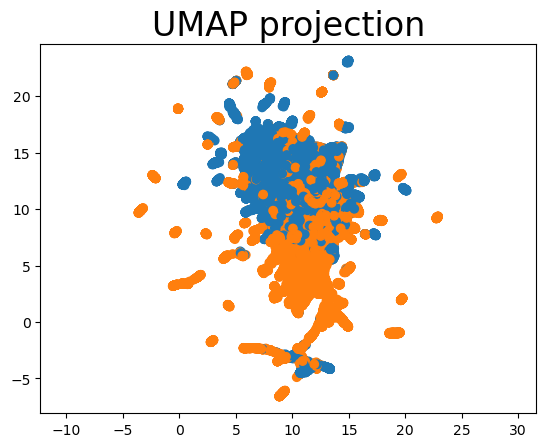

In [19]:
reducer = umap.UMAP(n_components=2)

embedding_umap = reducer.fit_transform(embeddings.detach().cpu().numpy())
y_cpu = ys.detach().cpu()

fig = plt.figure()
ax = fig.add_subplot()

ax.scatter(
    embedding_umap[:, 0],
    embedding_umap[:, 1],
    c=[sns.color_palette()[x] for x in y_cpu])

plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection', fontsize=24)